In [315]:
import pandas as pd

In [316]:
df = pd.read_csv("Airline.csv")
df.head(2)

,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,1,IndiGo,24-03-2019,Banglore,New Delhi,BLR _ DEL,22:20,22-03-2026 01:10,2h 50m,non-stop,No info,3897.0
1,2,Air India,01-05-2019,Kolkata,Banglore,CCU _ IXR _ BBI _ BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [317]:
df.isnull()

,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10684,False,False,False,False,False,False,False,False,False,False,False,False
10685,False,False,False,False,False,False,False,False,False,False,False,False
10686,False,False,False,False,False,False,False,False,False,False,False,False
10687,False,False,False,False,False,False,False,False,False,False,False,False


In [318]:
df[df['Price'].isnull()]
mean_Price = df["Price"].mean()
mean_Price
df.fillna({'Price':mean_Price},inplace=True)

In [319]:
mode_source = df['Source'].mode()[0]
mode_source
df.fillna({'Source':mode_source},inplace=True)

In [320]:
mode_Desti = df['Destination'].mode()[0]
mode_Desti
df.fillna({'Destination':mode_Desti},inplace=True)

In [321]:
df[df['Total_Stops'].isnull()]
mode_T_Stops = df['Total_Stops'].mode()[0]
df.fillna({'Total_Stops':mode_T_Stops},inplace=True)
df[df['Total_Stops'].isnull()]

,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [322]:
df['Destination'].value_counts()

Destination
Cochin       4539
Banglore     2873
Delhi        1267
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [323]:
df['Additional_Info']

0        No info
1        No info
2        No info
3        No info
4        No info
          ...   
10684    No info
10685    No info
10686    No info
10687    No info
10688    No info
Name: Additional_Info, Length: 10689, dtype: object

In [324]:
df.drop(['ID','Additional_Info','Route'],axis=1,inplace=True)

In [325]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [326]:
df['Total_Stops'] = df['Total_Stops'].replace({'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3,'4 stops':4})

/var/folders/bz/vww88h914wx19nvq5ks14p240000gn/T/ipykernel_3071/3998974832.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Total_Stops'] = df['Total_Stops'].replace({'non-stop':0, '2 stops':2, '1 stop':1, '3 stops':3,'4 stops':4})


In [327]:
df['Total_Stops'].value_counts()

Total_Stops
1    5626
0    3496
2    1521
3      45
4       1
Name: count, dtype: int64

In [328]:
df['DurHrs_Mins']=0
df

for i in df.index:
    DurCol = df.loc[i,'Duration']
    if " " in DurCol:
        colOne = DurCol.split(" ")[0]
        colTwo = DurCol.split(" ")[1]

        if "h" in colOne:
            colOne = int(colOne.replace("h",""))*60
        elif "m" in colOne:
            colOne = int(colOne.replace("m",""))

        if "h" in colTwo:
            colTwo = int(colTwo.replace("h",""))*60
        elif "m" in colTwo:
            colTwo = int(colTwo.replace("m",""))

            

        df.loc[i,'DurHrs_Mins'] = colOne + colTwo

    else:
        if "h" in DurCol:
            DurCol = int(DurCol.replace("h",""))*60
            df.loc[i,'DurHrs_Mins'] = DurCol
        elif "m" in DurCol:
            DurCol = int(DurCol.replace("m",""))


        



In [329]:
df['Date_of_Journey'].dtype

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'],format='mixed')
df['Dep_Time'] = pd.to_datetime(df['Dep_Time'],format='mixed')

df['D_Day'] = df['Date_of_Journey'].dt.day
df['D_Month'] = df['Date_of_Journey'].dt.month
df['D_Year'] = df['Date_of_Journey'].dt.year

df['D_Hour'] = df['Dep_Time'].dt.hour
df['D_Minute'] = df['Dep_Time'].dt.minute

In [330]:
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'],format='mixed')

In [331]:
df['NewCol'] = pd.to_datetime(df['Arrival_Time'],format='mixed')
df['A_Hour'] = df['NewCol'].dt.hour
df['A_Minute'] = df['NewCol'].dt.minute

df['A_Day'] = df['NewCol'].dt.day
df['A_Month'] = df['NewCol'].dt.month
df['A_Year'] = df['NewCol'].dt.year




In [332]:
df

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,DurHrs_Mins,...,D_Month,D_Year,D_Hour,D_Minute,NewCol,A_Hour,A_Minute,A_Day,A_Month,A_Year
0,IndiGo,2019-03-24,Banglore,New Delhi,2026-09-19 22:20:00,22-03-2026 01:10,2h 50m,0,3897.0,170,...,3,2019,22,20,2026-03-22 01:10:00,1,10,22,3,2026
1,Air India,2019-01-05,Kolkata,Banglore,2026-09-19 05:50:00,13:15,7h 25m,2,7662.0,445,...,1,2019,5,50,2026-09-19 13:15:00,13,15,19,9,2026
2,Jet Airways,2019-09-06,Delhi,Cochin,2026-09-19 09:25:00,10-06-2026 04:25,19h,2,13882.0,1140,...,9,2019,9,25,2026-10-06 04:25:00,4,25,6,10,2026
3,IndiGo,2019-12-05,Kolkata,Banglore,2026-09-19 18:05:00,23:30,5h 25m,1,6218.0,325,...,12,2019,18,5,2026-09-19 23:30:00,23,30,19,9,2026
4,IndiGo,2019-01-03,Banglore,New Delhi,2026-09-19 16:50:00,21:35,4h 45m,1,13302.0,285,...,1,2019,16,50,2026-09-19 21:35:00,21,35,19,9,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10684,Air Asia,2019-09-04,Kolkata,Banglore,2026-09-19 19:55:00,22:25,2h 30m,0,4107.0,150,...,9,2019,19,55,2026-09-19 22:25:00,22,25,19,9,2026
10685,Air India,2019-04-27,Kolkata,Banglore,2026-09-19 20:45:00,23:20,2h 35m,0,4145.0,155,...,4,2019,20,45,2026-09-19 23:20:00,23,20,19,9,2026
10686,Jet Airways,2019-04-27,Banglore,Delhi,2026-09-19 08:20:00,11:20,3h,0,7229.0,180,...,4,2019,8,20,2026-09-19 11:20:00,11,20,19,9,2026
10687,Vistara,2019-01-03,Banglore,New Delhi,2026-09-19 11:30:00,14:10,2h 40m,0,12648.0,160,...,1,2019,11,30,2026-09-19 14:10:00,14,10,19,9,2026


In [333]:
df = df.drop(['Date_of_Journey','Dep_Time','Arrival_Time','Duration','NewCol'],axis=1)

In [334]:
#  outlier handling


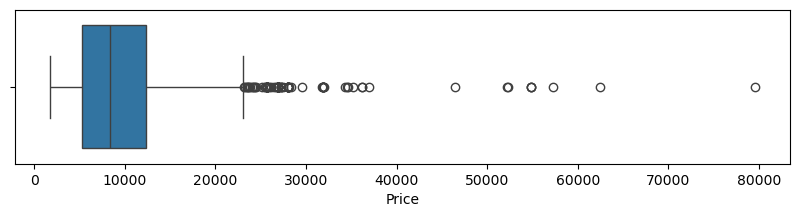

In [335]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,2))
sns.boxplot(x=df['Price'])
plt.show()

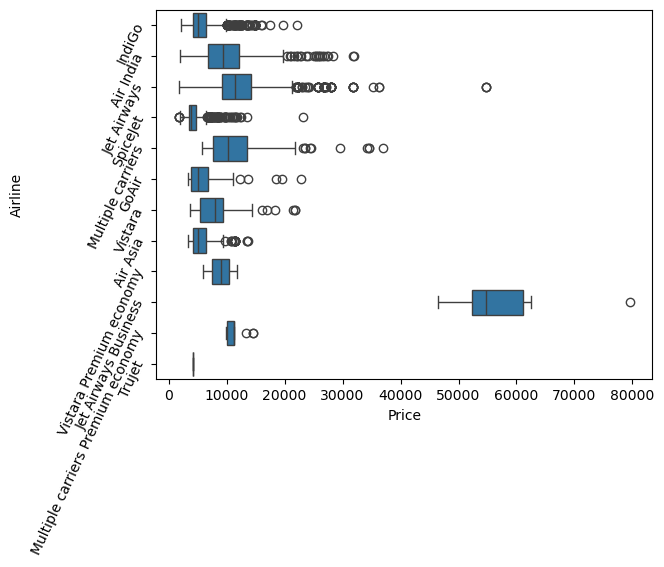

In [336]:
plt.Figure(figsize=(10,6))
sns.boxplot(x=df['Price'],y=df['Airline'])
plt.yticks(rotation=65)
plt.show()

In [337]:
### Rwmovw outlier 

In [338]:
import pandas as pd
df['Airline'].unique()


airlineName = { 'IndiGo':      [0.25,0.75],
                "Air India":   [0.27,0.75],
                'Jet Airways': [0.27,0.75],
                'SpiceJet':    [0.10,0.60],
                'Multiple carriers':[0.20,0.80],
                'GoAir':       [0.20,0.75],
                'Vistara':     [0.20,0.75],
                'Air Asia':    [0.25,0.75],
                'Vistara Premium economy':[0.25,0.75],
                'Jet Airways Business':[0.25,0.75],
                'Multiple carriers Premium economy':[0.20,0.75],
                'Trujet':       [0,0]

              }


final_df = pd.DataFrame(columns=list(df.columns))
final_df

list(df.columns)



for key,value in airlineName.items():
    airDataSet = ""
    airDataSet = df[df['Airline'] == key]

    q1 = airDataSet['Price'].quantile(value[0])
    q3 = airDataSet['Price'].quantile(value[1])
    IQR = q3-q1
    lowerLimit = q1-IQR*1.5
    upperLimit = q3+IQR*1.5
    lowerLimitIndex = airDataSet[airDataSet['Price']<=lowerLimit].index
    upperLimitIndex = airDataSet[airDataSet['Price']>=upperLimit].index

    

    if airDataSet.shape[0] > 5 : 
        airDataSet.drop(lowerLimitIndex,axis=0,inplace=True)
        airDataSet.drop(upperLimitIndex,axis=0,inplace=True)
    else:
        pass

    df[df.index.isin([2878])]


    #airDataSet1 = airDataSet1.append(airDataSet, ignore_index=True)  # ignore_index=True resets the index

    final_df = pd.concat([final_df, airDataSet], axis=0)  # axis=0 is the default and means appending vertically



/var/folders/bz/vww88h914wx19nvq5ks14p240000gn/T/ipykernel_3071/1070136267.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airDataSet.drop(lowerLimitIndex,axis=0,inplace=True)
/var/folders/bz/vww88h914wx19nvq5ks14p240000gn/T/ipykernel_3071/1070136267.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airDataSet.drop(upperLimitIndex,axis=0,inplace=True)
/var/folders/bz/vww88h914wx19nvq5ks14p240000gn/T/ipykernel_3071/1070136267.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when deter

<Axes: xlabel='Price', ylabel='Airline'>

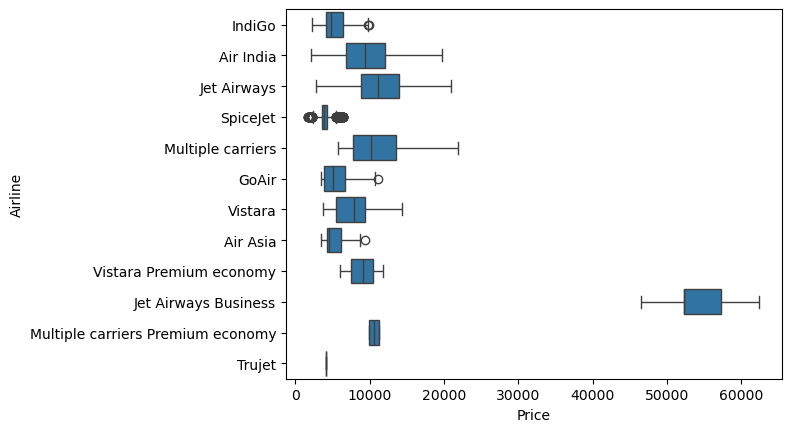

In [339]:
final_df
sns.boxplot(x=final_df['Price'],y=final_df['Airline'])

In [340]:
# Split in to y and X
y = df['Price']
y

X = df.drop(['Price'],axis=1)
X

,Airline,Source,Destination,Total_Stops,DurHrs_Mins,D_Day,D_Month,D_Year,D_Hour,D_Minute,A_Hour,A_Minute,A_Day,A_Month,A_Year
0,IndiGo,Banglore,New Delhi,0,170,24,3,2019,22,20,1,10,22,3,2026
1,Air India,Kolkata,Banglore,2,445,5,1,2019,5,50,13,15,19,9,2026
2,Jet Airways,Delhi,Cochin,2,1140,6,9,2019,9,25,4,25,6,10,2026
3,IndiGo,Kolkata,Banglore,1,325,5,12,2019,18,5,23,30,19,9,2026
4,IndiGo,Banglore,New Delhi,1,285,3,1,2019,16,50,21,35,19,9,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10684,Air Asia,Kolkata,Banglore,0,150,4,9,2019,19,55,22,25,19,9,2026
10685,Air India,Kolkata,Banglore,0,155,27,4,2019,20,45,23,20,19,9,2026
10686,Jet Airways,Banglore,Delhi,0,180,27,4,2019,8,20,11,20,19,9,2026
10687,Vistara,Banglore,New Delhi,0,160,3,1,2019,11,30,14,10,19,9,2026


In [341]:
# Train test Split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train_true,y_test_true =train_test_split(X,y,test_size=.20,random_state=42)


In [342]:
X_train.to_csv("/Users/vijaysabhavat/Documents/Airline_ML_Project_001/Data/CleanedData/X_train.csv",index=False) 

X_test.to_csv("/Users/vijaysabhavat/Documents/Airline_ML_Project_001/Data/CleanedData/X_test.csv",index=False) 
y_train_true.to_csv("/Users/vijaysabhavat/Documents/Airline_ML_Project_001/Data/CleanedData/y_train_true.csv",index=False)  
y_test_true.to_csv("/Users/vijaysabhavat/Documents/Airline_ML_Project_001/Data/CleanedData/y_test_true.csv",index=False)
